
image 1/1 /home/ubuntu/additional_drive/shwan_data/yolo_training/all_dataset_marge/images/val/19_crimes_sauignon_blance_frame_39.png: 640x384 2 19_crimes_sauignon_blances, 27.4ms
Speed: 2.3ms preprocess, 27.4ms inference, 35.0ms postprocess per image at shape (1, 3, 640, 384)


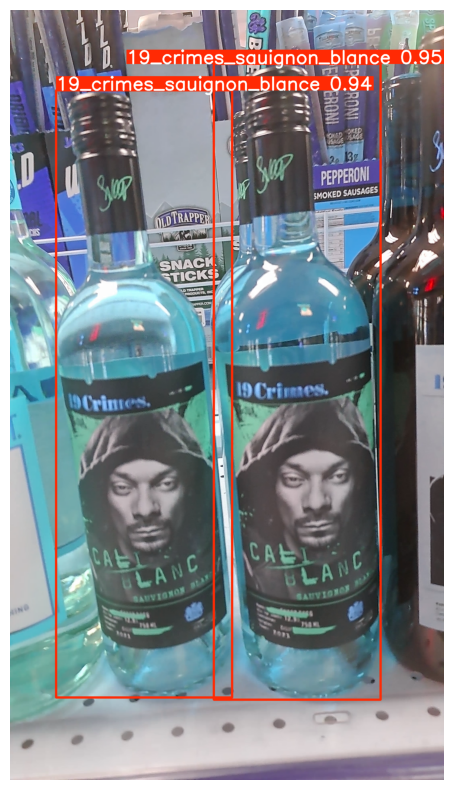

In [6]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

# ==== EDIT THESE ====
MODEL_PATH = '/home/ubuntu/additional_drive/shwan_data/yolo_training/best.pt'      # your YOLOv11 model file
IMAGE_PATH = "/home/ubuntu/additional_drive/shwan_data/yolo_training/all_dataset_marge/images/val/19_crimes_sauignon_blance_frame_39.png"    # your image file
CONFIDENCE = 0.7  # confidence threshold (adjust as needed)
# ====================

# Load model
model = YOLO(MODEL_PATH)

# Run prediction with confidence threshold
results = model(IMAGE_PATH, conf=CONFIDENCE)

# Display result in notebook
plt.figure(figsize=(10, 10))
plt.imshow(results[0].plot())  # draw bounding boxes
plt.axis("off")
plt.show()


In [2]:
# from moviepy import VideoFileClip

# input_path  = "/home/ubuntu/Videos/19_crime_rose/20251013_112042.mp4"
# output_path = "Video1_crop.mp4"
# start_time  = 5     # in seconds
# end_time    = 20    # up to 15s

# clip = VideoFileClip(input_path)

# # Option A: use slicing
# cropped = clip[start_time:end_time]

# # Option B: use the renamed method
# #   cropped = clip.subclipped(start_time, end_time)

# cropped.write_videofile(output_path,
#                         codec="libx264",
#                         audio_codec="aac")

# clip.close()
# cropped.close()

# print("✅ Saved:", output_path)


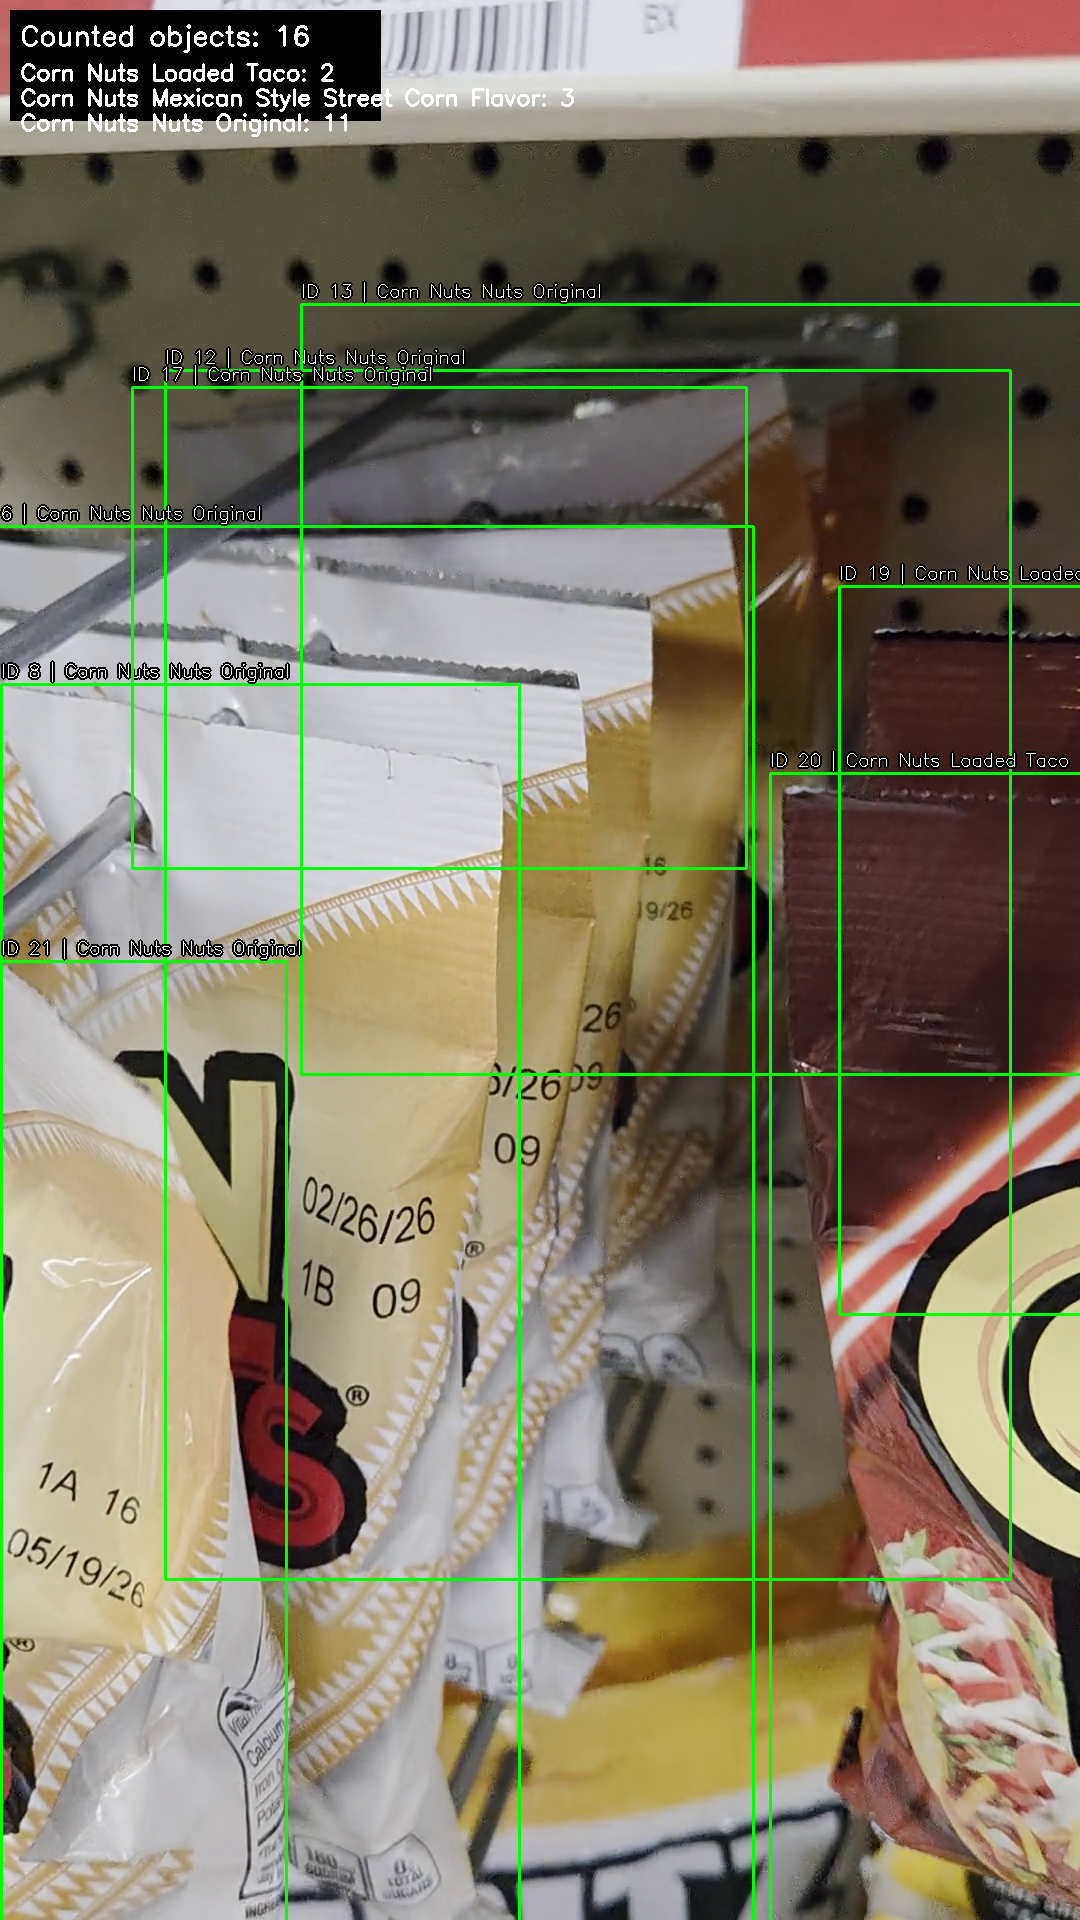

In [ ]:
import os
import cv2
import numpy as np
from collections import defaultdict
from ultralytics import YOLO
from IPython.display import display, clear_output
from PIL import Image
from deep_sort_realtime.deepsort_tracker import DeepSort

# ---------------- Config ----------------
weights = '/home/ubuntu/additional_drive/shwan_data/yolo_training/best.pt'
source = "/home/ubuntu/Videos/19_crime_rose/20251013_112042.mp4"
output_path = "output_tracked.mp4"

conf = 0.60
iou = 0.45
imgsz = 640
device = "0"

keep_input_fps = True
display_stride = 2
max_frames = None

min_visible_frames = 15   # object must persist this many frames before counting
# ---------------------------------------

model = YOLO(weights)

tracker = DeepSort(
    max_age=30,
    n_init=3,
    nms_max_overlap=1.0,
    max_cosine_distance=0.2,
    embedder="mobilenet",
    half=True,
    bgr=True
)

writer = None
os.makedirs(os.path.dirname(output_path) or ".", exist_ok=True)

def get_input_meta(src):
    cap = cv2.VideoCapture(src if not (isinstance(src, str) and src.isdigit()) else int(src))
    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)) or 0
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)) or 0
    cap.release()
    return fps, (w, h)

input_fps, _ = get_input_meta(source)
write_fps = input_fps if keep_input_fps and input_fps > 0 else 30

# Tracking stats
seen_ids_global = set()
seen_ids_per_class = defaultdict(set)
track_visibility = defaultdict(int)  # track_id -> number of frames visible

results_stream = model.predict(
    source=source,
    stream=True,
    conf=conf,
    iou=iou,
    imgsz=imgsz,
    device=device,
    verbose=False
)

frame_idx = 0
for result in results_stream:
    frame = result.orig_img
    if frame is None:
        continue

    dets = []
    if result.boxes is not None and len(result.boxes) > 0:
        xyxy = result.boxes.xyxy.cpu().numpy()
        confs = result.boxes.conf.cpu().numpy()
        clss = result.boxes.cls.cpu().numpy().astype(int)
        for (x1, y1, x2, y2), cf, ci in zip(xyxy, confs, clss):
            class_name = model.names.get(int(ci), str(int(ci)))
            dets.append([[float(x1), float(y1), float(x2), float(y2)], float(cf), class_name])

    tracks = tracker.update_tracks(dets, frame=frame)

    for t in tracks:
        if not t.is_confirmed():
            continue
        tid = int(t.track_id)
        cls_name = t.get_det_class()
        if cls_name is not None:
            cls_name = str(cls_name)

        ltrb = t.to_ltrb()
        x1, y1, x2, y2 = map(int, ltrb)

        # update visibility time
        track_visibility[tid] += 1

        # Count only if object has been visible for enough frames
        if track_visibility[tid] >= min_visible_frames:
            if tid not in seen_ids_global:
                seen_ids_global.add(tid)
                if cls_name:
                    seen_ids_per_class[cls_name].add(tid)

        # draw bounding box
        color = (0, 255, 0) if track_visibility[tid] >= min_visible_frames else (0, 165, 255)
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
        label = f"ID {tid}" + (f" | {cls_name}" if cls_name else "")
        cv2.putText(frame, label, (x1, max(0, y1 - 7)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 3)
        cv2.putText(frame, label, (x1, max(0, y1 - 7)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

    # HUD
    cv2.rectangle(frame, (10, 10), (380, 120), (0, 0, 0), -1)
    cv2.putText(frame, f"Counted objects: {len(seen_ids_global)}",
                (20, 45), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 255), 2)
    y = 80
    for k, v in sorted(seen_ids_per_class.items()):
        cv2.putText(frame, f"{k}: {len(v)}", (20, y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.75, (255, 255, 255), 2)
        y += 25

    if writer is None:
        h, w = frame.shape[:2]
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        writer = cv2.VideoWriter(output_path, fourcc, write_fps, (w, h))

    writer.write(frame)

    if (frame_idx % display_stride) == 0:
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        clear_output(wait=True)
        display(Image.fromarray(rgb))

    frame_idx += 1
    if max_frames is not None and frame_idx >= max_frames:
        break

if writer:
    writer.release()

print("\n=== Deep SORT Temporal Count Summary ===")
print(f"Saved annotated video to: {os.path.abspath(output_path)}")
print(f"Total counted (persisted) objects: {len(seen_ids_global)}")
for cls_name, ids in sorted(seen_ids_per_class.items(), key=lambda x: x[0]):
    print(f"  {cls_name}: {len(ids)}")
